In [6]:
from pathlib import Path
from scipy.io import loadmat
import scipy.signal as sgn
import pandas as pd
import numpy as np
import re
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score


In [ ]:
from Functions import remove_baseline_filter,  preprocess_one_file , stem_to_subject_id , prepare_split_data_loaders,training_curve_plot , WindowDataset, CNN1D, train_model_with_loaders, eval_loader_binary , run_one_experiment , select_channels

## Preprocessing step

In [8]:

folder = Path(r"C:\Users\saber\thesis_second_try\data\Rest\Respiration_ECG_Raw")


# Parameters
FS_IN = 1000
FS_OUT = 60
WIN_LEN = 2048
STRIDE = WIN_LEN  # non-overlap
batch_size = 64

SIGNAL_ORDER = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]

SCALE = {
    "ECG_mV": 1000.0,      # V -> mV
    "Fingerpulse": 10.0,
    "Cannula": 10.0,
    "Thermopod": 1.0
}

# ────────────────────────────────────────────────
# The baseline function 
SOS = remove_baseline_filter(FS_IN)

#────────────────────────────────────────────────
# Run over alla the files
mat_files = sorted(folder.glob("*.mat"))
participant_files = [f for f in mat_files if f.name.startswith("resting_state_participant_")]
print("Total .mat files:", len(mat_files))
print("Participant files:", len(participant_files))

#────────────────────────────────────────────────
# Split the files in mouth and nose 
nose_files, mouth_files, skipped = [], [], []
for f in participant_files:
    m = re.search(r"participant_(\d+)", f.stem)
    if not m:
        skipped.append(f.name)
        continue
    pid = int(m.group(1))
    if 10 <= pid <= 112:
        nose_files.append(f)
    elif 200 <= pid <= 312:
        mouth_files.append(f)
    else:
        skipped.append(f.name)

print("Nose files :", len(nose_files))
print("Mouth files:", len(mouth_files))
print("Skipped    :", len(skipped))

#────────────────────────────────────────────────
# Preprocess each group 
nose_tensors_by_participant = {}
mouth_tensors_by_participant = {}
failed = []
# 1. for nose 
for f in nose_files:
    try:
        nose_tensors_by_participant[f.stem] = preprocess_one_file(
            f,
            fs_in=FS_IN,
            fs_out=FS_OUT,
            win_len=WIN_LEN,
            stride=STRIDE,
            keep_signals=SIGNAL_ORDER,
            scale=SCALE,
            sos=SOS,
        )
    except Exception as e:
        failed.append((f.name, "nose", str(e)))
# 2. for mouth
for f in mouth_files:
    try:
        mouth_tensors_by_participant[f.stem] = preprocess_one_file(
            f,
            fs_in=FS_IN,
            fs_out=FS_OUT,
            win_len=WIN_LEN,
            stride=STRIDE,
            keep_signals=SIGNAL_ORDER,
            scale=SCALE,
            sos=SOS,
        )
    except Exception as e:
        failed.append((f.name, "mouth", str(e)))

print("Processed nose :", len(nose_tensors_by_participant))
print("Processed mouth:", len(mouth_tensors_by_participant))
print("Failed:", len(failed))

#────────────────────────────────────────────────
# Stacking the tensors 
if len(nose_tensors_by_participant) > 0:
    nose_keys = sorted(nose_tensors_by_participant.keys())
    X_nose = np.stack([nose_tensors_by_participant[k] for k in nose_keys], axis=0)
    print("X_nose shape:", X_nose.shape)  # (P_nose, n_windows, 2, 2048)

if len(mouth_tensors_by_participant) > 0:
    mouth_keys = sorted(mouth_tensors_by_participant.keys())
    X_mouth = np.stack([mouth_tensors_by_participant[k] for k in mouth_keys], axis=0)
    print("X_mouth shape:", X_mouth.shape)  # (P_mouth, n_windows, 2, 2048)


Total .mat files: 207
Participant files: 205
Nose files : 102
Mouth files: 103
Skipped    : 0
Processed nose : 102
Processed mouth: 103
Failed: 0
X_nose shape: (102, 9, 4, 2048)
X_mouth shape: (103, 9, 4, 2048)


In [9]:
# Checking that everything is working
nose_keys = sorted(nose_tensors_by_participant.keys()) 
# print(nose_keys)
print("X_nose shape:", X_nose .shape)
X_nose = np.stack([nose_tensors_by_participant[k] for k in nose_keys], axis=0)
print("First 5 keys:", nose_keys[:5])

X_nose shape: (102, 9, 4, 2048)
First 5 keys: ['resting_state_participant_010', 'resting_state_participant_011', 'resting_state_participant_012', 'resting_state_participant_013', 'resting_state_participant_014']


## Dataframe for the mouth 
The df was previously save cleaned and saved locally 

In [10]:
import pandas as pd
Path_subject = r"df_nose.csv"
df_nose= pd.read_csv(Path_subject)
df_nose.head()

,Subject Number,Gender,Age
0,10,1,37
1,11,1,29
2,12,0,25
3,13,0,31
4,14,0,28


In [11]:
gender_by_subject = dict(zip(df_nose["Subject Number"], df_nose["Gender"]))
gender_by_subject # this is subject id and their correct gender 


{10: 1,
 11: 1,
 12: 0,
 13: 0,
 14: 0,
 15: 0,
 16: 0,
 17: 0,
 18: 0,
 19: 0,
 20: 1,
 21: 0,
 22: 0,
 23: 0,
 24: 0,
 25: 0,
 26: 0,
 27: 0,
 28: 1,
 29: 1,
 30: 1,
 31: 0,
 33: 0,
 34: 0,
 35: 0,
 36: 0,
 37: 1,
 38: 0,
 39: 1,
 40: 0,
 41: 0,
 42: 0,
 43: 0,
 44: 0,
 45: 0,
 46: 0,
 47: 0,
 48: 1,
 49: 0,
 50: 1,
 51: 0,
 52: 0,
 53: 1,
 54: 1,
 55: 0,
 56: 0,
 57: 1,
 58: 0,
 59: 1,
 60: 0,
 61: 0,
 62: 0,
 63: 0,
 64: 1,
 65: 0,
 66: 0,
 67: 1,
 68: 1,
 69: 1,
 70: 1,
 71: 0,
 72: 0,
 73: 1,
 74: 0,
 75: 0,
 76: 0,
 77: 1,
 78: 0,
 79: 0,
 80: 0,
 81: 0,
 82: 0,
 83: 0,
 84: 0,
 85: 1,
 86: 1,
 87: 1,
 88: 0,
 89: 0,
 90: 0,
 91: 1,
 92: 0,
 93: 1,
 94: 0,
 95: 1,
 96: 0,
 97: 1,
 98: 1,
 99: 1,
 100: 1,
 101: 1,
 102: 0,
 103: 1,
 104: 0,
 105: 1,
 106: 0,
 107: 0,
 108: 1,
 109: 1,
 110: 0,
 111: 0,
 112: 1}

In [14]:
nose_ids_from_files = np.array([stem_to_subject_id(k) for k in nose_keys], dtype=int)

print("First 10 subject IDs from files:", nose_ids_from_files[:10])
print("Number of participants from files:", len(nose_ids_from_files))
print("Unique IDs:", len(np.unique(nose_ids_from_files)))


# mouth_ids_for_labels = mouth_ids_from_files - 200

print("First 10 raw mouth IDs:   ", nose_ids_from_files[:10])
# print("First 10 mapped label IDs:", mouth_ids_for_labels[:10])

y_nose = np.array([gender_by_subject[sid] for sid in nose_ids_from_files], dtype=int)
print("y_nose gender:", y_nose)
print("y_nose shape:", y_nose.shape)
print("Gender counts [0,1]:", np.bincount(y_nose))


First 10 subject IDs from files: [10 11 12 13 14 15 16 17 18 19]
Number of participants from files: 102
Unique IDs: 102
First 10 raw mouth IDs:    [10 11 12 13 14 15 16 17 18 19]
y_nose gender: [1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0
 1 0 1 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0
 1 1 1 0 0 0 1 0 1 0 1 0 1 1 1 1 1 0 1 0 1 0 0 1 1 0 0 1]
y_nose shape: (102,)
Gender counts [0,1]: [65 37]


# The split 

In [15]:


train_loader, val_loader, test_loader, meta = prepare_split_data_loaders(
    X_nose, y_nose,
    seed=6,
    batch_size=batch_size,
    normalize=True,
    return_meta=True
)

# baseline: majority-class accuracy on validation participants
X_val_p = meta["X_val_p"]
y_val_p = meta["y_val_p"]
baseline_acc = max(np.mean(y_val_p == 0), np.mean(y_val_p == 1))
# ────────────────────────────────────────────────
#  Quick sanity checks on test set 

print("\nFirst 20 test window labels:", meta['y_test'][10:40])

print("Example test window [0] – channel means:", meta['X_test'][0].mean(axis=1))

# If you want to see beginning of first channel of first test window:
print("Example test window[0] channel 0 – first 30 values:")
print(meta['X_test'][0, 0, :30])

X_mouth:     (102, 9, 4, 2048)
y_mouth:     (102,)   unique: [0 1]   counts: [65 37]

After normalization (train mean per ch): [-2.6680533e-09  4.5378734e-10  2.7411160e-09  7.5750801e-09]
After normalization (train std  per ch): [0.99999964 0.9999998  0.9999999  0.99999964]

Window-level shapes:
X_train:     (576, 4, 2048)  y_train: (576,)  counts: [369 207]
X_val  :     (153, 4, 2048)  y_val  : (153,)  counts: [99 54]
X_test :     (189, 4, 2048)  y_test : (189,)  counts: [117  72]

First 20 test window labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0]
Example test window [0] – channel means: [ 0.00201165 -0.00027668 -0.00085785 -0.0002708 ]
Example test window[0] channel 0 – first 30 values:
[-0.15468664 -0.20944187  0.0113573  -0.00712441 -0.01802046 -0.26778373
 -0.36157084 -0.35898265 -0.19587593 -0.02024161  4.2535367   1.7092631
 -1.284979    0.24923901 -0.17638147  0.13319993  0.03211309  0.2691964
  0.24082163  0.3723247   0.5234933   0.72161585  1.107011  

## Training step 

Epoch 01 | train loss 0.8304 acc 0.686 | val loss 0.8664 acc 0.471
Epoch 02 | train loss 0.7994 acc 0.717 | val loss 0.8456 acc 0.608
Epoch 03 | train loss 0.7720 acc 0.717 | val loss 0.8332 acc 0.601
Epoch 04 | train loss 0.7639 acc 0.729 | val loss 0.8280 acc 0.614
Epoch 05 | train loss 0.7337 acc 0.738 | val loss 0.8250 acc 0.634
Epoch 06 | train loss 0.7455 acc 0.724 | val loss 0.8226 acc 0.627
Epoch 07 | train loss 0.7377 acc 0.719 | val loss 0.8201 acc 0.621
Epoch 08 | train loss 0.7342 acc 0.740 | val loss 0.8171 acc 0.627
Epoch 09 | train loss 0.7258 acc 0.720 | val loss 0.8163 acc 0.627
Epoch 10 | train loss 0.7172 acc 0.750 | val loss 0.8165 acc 0.621
Epoch 11 | train loss 0.7077 acc 0.740 | val loss 0.8153 acc 0.621
Epoch 12 | train loss 0.7050 acc 0.734 | val loss 0.8194 acc 0.627
Epoch 13 | train loss 0.6892 acc 0.745 | val loss 0.8205 acc 0.634
Epoch 14 | train loss 0.6841 acc 0.752 | val loss 0.8094 acc 0.641
Epoch 15 | train loss 0.6710 acc 0.766 | val loss 0.8088 acc 0

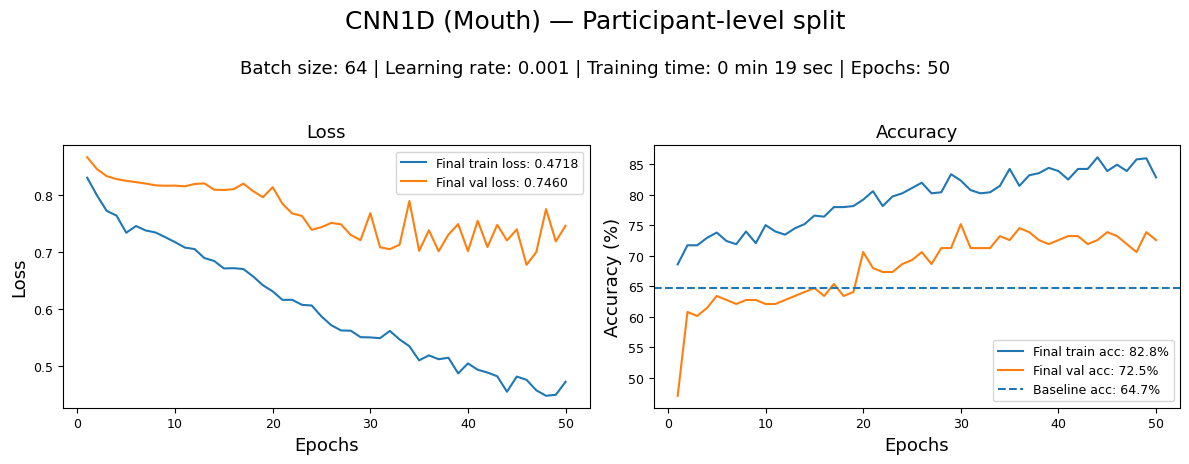

In [16]:
Epochs = 50 
lr = 1e-3
patience=10 

model = CNN1D(len(SIGNAL_ORDER))


t0 = time.time()
model, trL, vaL, trA, vaA, trP, valP, _= train_model_with_loaders(
    model,
    train_loader,
    val_loader,
    epochs=Epochs,
    lr=lr,
    patience=patience,
    use_pos_weight=True
)
t1 = time.time()


print("Final train acc:", trA[-1])
print("Final val acc:", vaA[-1])

training_curve_plot(
    title="CNN1D (Mouth) — Participant-level split",
    train_losses=trL,
    val_losses=vaL,
    train_accs=trA,
    val_accs=vaA,
    batch_size=64,
    learning_rate=0.001,
    training_time=(t1 - t0),
    baseline_acc=baseline_acc
)

## The evalutaion section

In [17]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score

def eval_loader_binary(model, loader, device=None, threshold=0.5, verbose=True, name="LOADER"):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)
    model.eval()

    y_prob_list, y_true_list, y_pred_list = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)

            logits = model(xb).view(-1)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            preds = (probs >= threshold).astype(int)

            y_prob_list.append(probs)
            y_pred_list.append(preds)
            y_true_list.append(yb.detach().cpu().numpy().astype(int).reshape(-1))

    y_true = np.concatenate(y_true_list) if y_true_list else np.array([], dtype=int)
    y_pred = np.concatenate(y_pred_list) if y_pred_list else np.array([], dtype=int)
    y_prob = np.concatenate(y_prob_list) if y_prob_list else np.array([], dtype=float)

    acc = accuracy_score(y_true, y_pred) if len(y_true) else float("nan")

    if verbose:
        print(f"{name} accuracy (window-level): {acc:.4f}")

    return y_true, y_pred, y_prob, acc


In [18]:
print(eval_loader_binary)


<function eval_loader_binary at 0x000002050063B1C0>


In [19]:
y_tr, yhat_tr, p_tr, acc_tr = eval_loader_binary(model, train_loader, name="TRAIN")
y_va, yhat_va, p_va, acc_va = eval_loader_binary(model, val_loader,   name="VAL")
y_te, yhat_te, p_te, acc_te = eval_loader_binary(model, test_loader,  name="TEST")


TRAIN accuracy (window-level): 0.8594
VAL accuracy (window-level): 0.7320
TEST accuracy (window-level): 0.6614


In [20]:
# for the test


print(f"Accuracy:           {accuracy_score(y_te, yhat_te):.4f}")
print(f"Balanced acc:       {balanced_accuracy_score(y_te, yhat_te):.4f}")
print(f"F1 (positive):      {f1_score(y_te, yhat_te):.4f}")
print(f"ROC AUC:            {roc_auc_score(y_te, p_te):.4f}")
print(f"Average Precision:  {average_precision_score(y_te, p_te):.4f}")

print("\nCM:\n", confusion_matrix(y_te, yhat_te))
print(classification_report(y_te, yhat_te, digits=4))


Accuracy:           0.6614
Balanced acc:       0.6357
F1 (positive):      0.5429
ROC AUC:            0.5887
Average Precision:  0.5300

CM:
 [[87 30]
 [34 38]]
              precision    recall  f1-score   support

           0     0.7190    0.7436    0.7311       117
           1     0.5588    0.5278    0.5429        72

    accuracy                         0.6614       189
   macro avg     0.6389    0.6357    0.6370       189
weighted avg     0.6580    0.6614    0.6594       189



In [21]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Put your data in a list of tuples
datasets = [
    ("TRAIN", y_tr,  yhat_tr,  p_tr),
    ("VAL",   y_va,  yhat_va,  p_va),
    ("TEST",  y_te,  yhat_te,  p_te),
]

for name, y_true, y_pred, y_prob in datasets:
    print(f"\n ----- {name}----")
    
    acc     = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred)
    auc     = roc_auc_score(y_true, y_prob)
    ap      = average_precision_score(y_true, y_prob)
    
    print(f"Accuracy:              {acc:.4f}")
    print(f"Balanced accuracy:     {bal_acc:.4f}")
    print(f"F1 (positive class):   {f1:.4f}")
    print(f"ROC AUC:               {auc:.4f}")
    print(f"Average Precision:     {ap:.4f}")
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    
    print("━" * 50)


 ----- TRAIN----
Accuracy:              0.8594
Balanced accuracy:     0.8648
F1 (positive class):   0.8188
ROC AUC:               0.9508
Average Precision:     0.9186

Confusion Matrix:
[[312  57]
 [ 24 183]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9286    0.8455    0.8851       369
           1     0.7625    0.8841    0.8188       207

    accuracy                         0.8594       576
   macro avg     0.8455    0.8648    0.8519       576
weighted avg     0.8689    0.8594    0.8613       576

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 ----- VAL----
Accuracy:              0.7320
Balanced accuracy:     0.7172
F1 (positive class):   0.6372
ROC AUC:               0.8283
Average Precision:     0.7374

Confusion Matrix:
[[76 23]
 [18 36]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8085    0.7677    0.7876        99
           1     0.6102    0.6667    0.6372        

In [ ]:


# print(f"Accuracy:           {accuracy_score(y_true, y_pred):.4f}")
# print(f"Balanced acc:       {balanced_accuracy_score(y_true, y_pred):.4f}")
# print(f"F1 (positive):      {f1_score(y_true, y_pred):.4f}")
# print(f"ROC AUC:            {roc_auc_score(y_true, y_prop):.4f}")
# print(f"Average Precision:  {average_precision_score(y_true, y_prop):.4f}")
# print("\nCM:\n", confusion_matrix(y_true, y_pred))
# print(classification_report(y_true, y_pred, digits=4))

In [28]:


FULL_SIGNAL_ORDER = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]

signal_sets = [
    ["ECG_mV"],
    ["Fingerpulse"],
    ["Cannula"],                          # 1 signal
    ["Thermopod"],                        # 1 signal
    #["Cannula", "Thermopod"],             # 2 signals
    ["ECG_mV", "Fingerpulse"],            # 2 signals
    ["ECG_mV", "Cannula"],            # 2 signals
    ["ECG_mV", "Thermopod"],            # 2 signals
    ["ECG_mV", "Fingerpulse","Thermopod"],   # 3 signals
    ["ECG_mV", "Fingerpulse", "Cannula"],   # 3 signals
    FULL_SIGNAL_ORDER,                    # 4 signals
]

seeds = [1, 2, 3, 4, 5]


In [29]:
results = []
for keep in signal_sets:
    for seed in seeds:
        m = run_one_experiment(
            X_full=X_nose,
            y=y_nose,
            full_order=FULL_SIGNAL_ORDER,
            keep_signals=keep,
            seed=seed,
            Epochs=50,
            lr=1e-3,
            patience=10,
            batch_size=64,
        )
        print(f"done: seed={seed}, signals={keep} -> acc={m['test_acc']:.3f}, auc={m['test_roc_auc']:.3f}")
        results.append(m)


Epoch 01 | train loss 0.8884 acc 0.460 | val loss 0.8777 acc 0.346
Epoch 02 | train loss 0.8772 acc 0.510 | val loss 0.8763 acc 0.405
Epoch 03 | train loss 0.8762 acc 0.516 | val loss 0.8751 acc 0.412
Epoch 04 | train loss 0.8554 acc 0.602 | val loss 0.8763 acc 0.373
Epoch 05 | train loss 0.8456 acc 0.616 | val loss 0.8780 acc 0.386
Epoch 06 | train loss 0.8410 acc 0.608 | val loss 0.8810 acc 0.412
Epoch 07 | train loss 0.8262 acc 0.641 | val loss 0.8863 acc 0.510
Epoch 08 | train loss 0.8236 acc 0.648 | val loss 0.8873 acc 0.497
Epoch 09 | train loss 0.8151 acc 0.670 | val loss 0.8868 acc 0.503
Epoch 10 | train loss 0.8220 acc 0.634 | val loss 0.8970 acc 0.601
Epoch 11 | train loss 0.8119 acc 0.642 | val loss 0.8943 acc 0.516
Epoch 12 | train loss 0.7975 acc 0.668 | val loss 0.8945 acc 0.503
Epoch 13 | train loss 0.7908 acc 0.649 | val loss 0.8983 acc 0.667
Early stopping at epoch 13
done: seed=1, signals=['ECG_mV'] -> acc=0.608, auc=0.635
Epoch 01 | train loss 0.8956 acc 0.488 | val 